In [1]:
from tabpfn_client import TabPFNClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm
import json
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer



def tabpfn_predict_proba(X_train, y_train, X_test):
    """Fit TabPFNClassifier on train and return positive-class probabilities for test."""
    mdl = TabPFNClassifier(ignore_pretraining_limits=True)
    mdl.fit(X_train, y_train)
    return mdl.predict_proba(X_test)[:, 1]


def binarize(s):
    print(s.value_counts())
    counts = s.value_counts()
    minority_class = counts.idxmin()
    majority_class = counts.idxmax()
    binary_series = s.map({minority_class: 1, majority_class: 0})
    return binary_series


def split_data(X, y, test_size, random=False):
    if random:
        return train_test_split(X, y, stratify=y, test_size=test_size)
    else:
        pos_idxs = []
        for idx, y_ in enumerate(list(y)):
            if y_ == 1:
                pos_idxs += [idx]

        n = int(len(pos_idxs) * (1 - test_size))
        cut_idx = pos_idxs[n]

        X_test = X.iloc[cut_idx:]
        y_test = y.iloc[cut_idx:]
        X_train = X.iloc[:cut_idx]
        y_train = y.iloc[:cut_idx]

        return X_train, X_test, y_train, y_test


In [ ]:
import tabpfn_client

# Paste your new API key here and run this cell before running any TabPFN cells
tabpfn_client.set_access_token("your_api_key_here")

In [5]:






def cv_tabpfn(df, test_size=0.33, random=True, impute=False):
    columns = list(df.columns)
    df = df[df[columns[0]].notnull()]
    y = binarize(df[columns[0]])
    x = df[columns[1:]]
    x_train, x_test, y_train, y_test = split_data(x, y, test_size, random)
    if impute:
        imputer = SimpleImputer()
        imputer.fit(x_train)
        x_train = imputer.transform(x_train)
        x_test = imputer.transform(x_test)
    print("TabPFN Classifier")
    mdl = TabPFNClassifier(ignore_pretraining_limits=True)
    mdl.fit(x_train, y_train)
    print("Training done")
    y_hat = mdl.predict_proba(x_test)[:,1]
    print("Predicting done")
    fpr, tpr, _ = roc_curve(y_test, y_hat)
    data = {"fpr": [float(x) for x in fpr], "tpr": [float(x) for x in tpr], "auroc": auc(fpr, tpr)}
    print(data["auroc"])
    return data


dataset_names = ["ml_d1_predelivery", "ml_d2_earlydeath", "ml_d3_latedeath"]

for dn in dataset_names:
    df = pd.read_csv("../data/processed/{0}.csv".format(dn))
    cv_data = []
    for _ in tqdm(range(10)):
        cv_data += [cv_tabpfn(df, random=True)]
    with open("../results/cv_{0}.json".format(dn), "w") as f:
        json.dump(cv_data, f, indent=4)

  0%|          | 0/10 [00:00<?, ?it/s]

Outcome Death
Live birth                   10422
Miscarriage or Stillbirth      174
Name: count, dtype: int64


NameError: name 'split_data' is not defined

Early Neonatal Death
Alive    10297
Dead       112
Name: count, dtype: int64

In [15]:
mdl = TabPFNClassifier(ignore_pretraining_limits=True)
mdl.fit(df, df["Pre-term Delivery"])

/home/mduranfrigola/miniconda3/envs/tabpfn/lib/python3.12/site-packages/tabpfn/classifier.py:421: UserWarning: Number of samples 10422 is greater than the maximum Number of samples 10000 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFNClassifier(ignore_pretraining_limits=True)

In [11]:
df

,Pre-term Delivery,Miscarriage,Outcome Death,Maternal Age,School Level,Years of Education,Parity,Maternal Height,Maternal Weight,Multiple Birth
0,Term,No miscarriage,Live birth,28.0,3=School,7.0,2.0,167.0,87.0,0.0
1,Term,No miscarriage,Live birth,19.0,3=School,7.0,0.0,154.0,66.0,0.0
2,Term,No miscarriage,Live birth,32.0,3=School,7.0,2.0,NaN,67.0,0.0
3,Term,No miscarriage,Live birth,32.0,3=School,9.0,3.0,154.0,97.0,0.0
4,Term,No miscarriage,Live birth,17.0,3=School,6.0,1.0,153.0,71.0,0.0
...,...,...,...,...,...,...,...,...,...,...
10591,Term,No miscarriage,Live birth,22.0,3=School,11.0,0.0,166.0,NaN,0.0
10592,Preterm,No miscarriage,Live birth,22.0,3=School,10.0,0.0,154.0,NaN,0.0
10593,Preterm,No miscarriage,Live birth,36.0,3=School,9.0,3.0,154.0,NaN,0.0
10594,Preterm,No miscarriage,Live birth,19.0,3=School,7.0,0.0,NaN,55.0,0.0


Outcome Death
Live birth                   10422
Miscarriage or Stillbirth      174
Name: count, dtype: int64

ml_d1_predelivery: 174 positives / 10596 total (1.64%)
  fold 1/5 ...


Processing: 100%|██████████| [00:02<00:00]


  fold 2/5 ...


Processing: 100%|██████████| [00:02<00:00]


  fold 3/5 ...


...

  fold 4/5 ...


Processing: 100%|██████████| [00:02<00:00]


  fold 5/5 ...


Processing: 100%|██████████| [00:02<00:00]


  x-axis: [0, 0.0206]  |  bins: 5

Saved calibration data to ../results/calibration_tabpfn.json


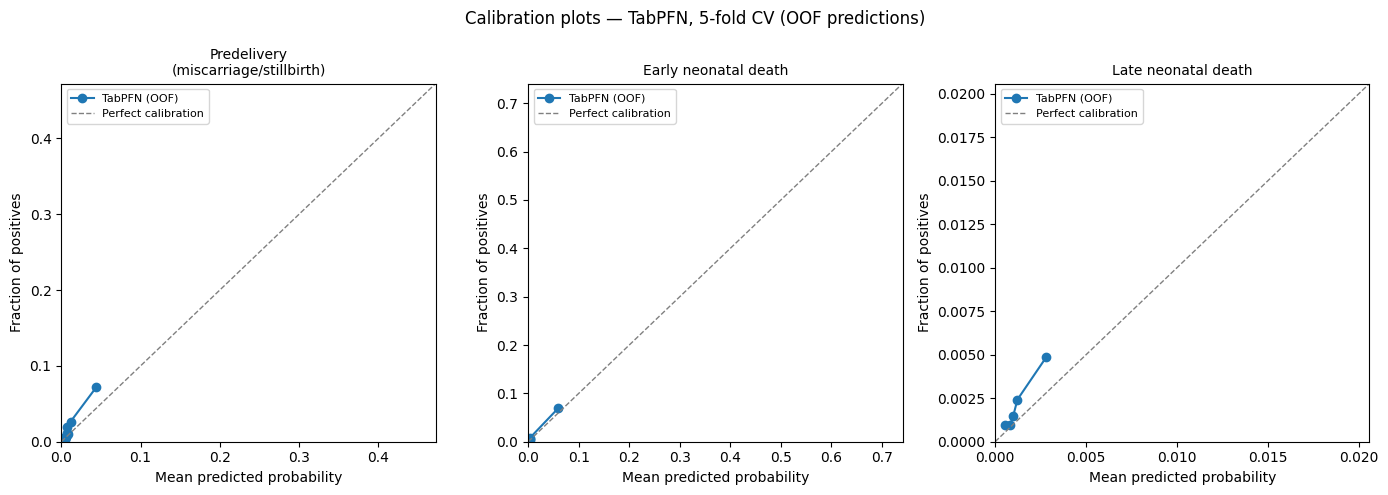

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import json
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold

dataset_names = ["ml_d1_predelivery", "ml_d2_earlydeath", "ml_d3_latedeath"]
dataset_labels = {
    "ml_d1_predelivery": "Predelivery\n(miscarriage/stillbirth)",
    "ml_d2_earlydeath": "Early neonatal death",
    "ml_d3_latedeath": "Late neonatal death",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
calibration_save = {}

for ax, dataset_name in zip(axes, dataset_names):
    df = pd.read_csv(f"../data/processed/{dataset_name}.csv")
    columns = list(df.columns)
    df = df[df[columns[0]].notnull()].copy()
    y = binarize(df[columns[0]])
    X = df[columns[1:]]
    X = X

    n_pos = int(y.sum())
    print(f"\n{dataset_name}: {n_pos} positives / {len(y)} total ({100*n_pos/len(y):.2f}%)")

    # 5-fold stratified CV — pool OOF predictions for calibration
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_prob_oof = np.zeros(len(y))

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        print(f"  fold {fold}/5 ...")
        X_train_np = X.iloc[train_idx].values
        X_test_np  = X.iloc[test_idx].values
        y_train    = y.iloc[train_idx].values
        y_prob_oof[test_idx] = tabpfn_predict_proba(X_train_np, y_train, X_test_np)

    # Calibration curve — fewer bins for very sparse positives
    n_bins = max(3, min(10, n_pos // 4))
    prob_true, prob_pred = calibration_curve(y, y_prob_oof, n_bins=n_bins, strategy="quantile")

    calibration_save[dataset_name] = {
        "prob_true": [float(v) for v in prob_true],
        "prob_pred": [float(v) for v in prob_pred],
        "n_bins": n_bins,
        "n_positive": n_pos,
        "n_samples": len(y),
        "y_true": [int(v) for v in y],
        "y_prob_oof": [float(v) for v in y_prob_oof],
    }

    x_max = float(np.quantile(y_prob_oof, 0.999))
    y_max = max(float(prob_true.max()) * 1.15, x_max)

    ax.plot(prob_pred, prob_true, marker="o", linewidth=1.5, label="TabPFN (OOF)")
    ax.plot([0, max(x_max, y_max)], [0, max(x_max, y_max)], linestyle="--", color="gray",
            linewidth=1, label="Perfect calibration")
    ax.set_title(dataset_labels[dataset_name], fontsize=10)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.legend(fontsize=8)
    print(f"  x-axis: [0, {x_max:.4f}]  |  bins: {n_bins}")

with open("../results/calibration_tabpfn.json", "w") as f:
    json.dump(calibration_save, f, indent=4)
print("\nSaved calibration data to ../results/calibration_tabpfn.json")

plt.suptitle("Calibration plots — TabPFN, 5-fold CV (OOF predictions)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/calibration_tabpfn.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

SITE_COLS = ["Delivery Place"]
N_BOOTSTRAP = 10
TEST_SIZE = 0.33

dataset_names = ["ml_d1_predelivery", "ml_d2_earlydeath", "ml_d3_latedeath"]
dataset_labels = {
    "ml_d1_predelivery": "Predelivery\n(miscarriage/stillbirth)",
    "ml_d2_earlydeath": "Early neonatal death",
    "ml_d3_latedeath": "Late neonatal death",
}


def encode_features(X):
    X_enc = X.copy()
    for col in X_enc.select_dtypes(include=["object", "category"]).columns:
        codes = pd.Categorical(X_enc[col]).codes.astype("float64")
        codes[codes == -1] = np.nan
        X_enc[col] = codes
    return X_enc.apply(pd.to_numeric, errors="coerce")


def xgb_predict_proba(X_train, y_train, X_test):
    mdl = XGBClassifier(n_estimators=100, random_state=42, eval_metric="auc",
                        n_jobs=-1, verbosity=0)
    mdl.fit(X_train, y_train)
    return mdl.predict_proba(X_test)[:, 1]


def run_bootstrap_auroc(X_enc, y, n_bootstrap=N_BOOTSTRAP, test_size=TEST_SIZE):
    sss = StratifiedShuffleSplit(n_splits=n_bootstrap, test_size=test_size, random_state=42)
    aurocs = []
    for train_idx, test_idx in sss.split(X_enc, y):
        X_train = X_enc.iloc[train_idx].values
        X_test  = X_enc.iloc[test_idx].values
        y_train = y.iloc[train_idx].values
        y_test  = y.iloc[test_idx]
        y_prob  = xgb_predict_proba(X_train, y_train, X_test)
        aurocs.append(roc_auc_score(y_test, y_prob))
    return aurocs


results = {}

for dataset_name in dataset_names:
    print(f"\n{dataset_name}")
    df = pd.read_csv(f"../data/processed/{dataset_name}.csv")
    columns = list(df.columns)
    df = df[df[columns[0]].notnull()].copy()
    y = binarize(df[columns[0]])
    X = df[columns[1:]]

    print(f"  Normal ({N_BOOTSTRAP} bootstrap iterations) ...")
    aurocs_normal = run_bootstrap_auroc(encode_features(X), y)
    print(f"  AUROC: {np.mean(aurocs_normal):.4f} ± {np.std(aurocs_normal, ddof=1):.4f}")

    X_perm = X.copy()
    rng = np.random.default_rng(42)
    permuted_cols = [c for c in SITE_COLS if c in X_perm.columns]
    for col in permuted_cols:
        X_perm[col] = rng.permutation(X_perm[col].values)
    print(f"  Permuted {permuted_cols} ({N_BOOTSTRAP} bootstrap iterations) ...")
    aurocs_perm = run_bootstrap_auroc(encode_features(X_perm), y)
    print(f"  AUROC: {np.mean(aurocs_perm):.4f} ± {np.std(aurocs_perm, ddof=1):.4f}")

    results[dataset_name] = {"normal": aurocs_normal, "permuted": aurocs_perm}

save_data = {dn: {k: [float(v) for v in vs] for k, vs in r.items()} for dn, r in results.items()}
with open("../results/site_permutation_xgb.json", "w") as f:
    json.dump(save_data, f, indent=4)
print("\nSaved to ../results/site_permutation_xgb.json")

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, dataset_name in zip(axes, dataset_names):
    normal = results[dataset_name]["normal"]
    perm   = results[dataset_name]["permuted"]

    bp = ax.boxplot([normal, perm], labels=["Normal", "Site\npermuted"],
                    widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.5),
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][1].set_facecolor("salmon")

    for i, vals in enumerate([normal, perm], 1):
        ax.scatter([i] * len(vals), vals, color="black", s=10, zorder=3, alpha=0.4)

    ax.set_title(dataset_labels[dataset_name], fontsize=10)
    ax.set_ylabel("AUROC")
    ax.set_ylim(0, 1)

plt.suptitle(f"AUROC: normal vs. Delivery Place permuted\n"
             f"(XGBoost, {N_BOOTSTRAP} bootstrap splits)", fontsize=11)
plt.tight_layout()
plt.savefig("../results/site_permutation_xgb.png", dpi=150, bbox_inches="tight")
plt.show()



ml_d1_predelivery
Outcome Death
Live birth                   10422
Miscarriage or Stillbirth      174
Name: count, dtype: int64
  Normal (100 bootstrap iterations) ...


KeyboardInterrupt: 